# Descriptive Statistics — Exploring a PostgreSQL Database on Azure

This notebook shows how to:

1. **Connect to a PostgreSQL database hosted on Azure** (the same server used by the VS Code PostgreSQL extension),
2. **Pull data into pandas DataFrames** with SQL, and
3. **Explore it with the standard descriptive-statistics plots** — histogram, density, ECDF, bar chart, box plot, violin plot, scatter plot, time line, and correlation heatmap — with notes on *which question each plot answers*, and
4. **Run basic statistical inference** — hypothesis tests (t-test, chi-square) and linear & logistic regression with `scipy` and `statsmodels`.

**The data.** The `classproject` database backs the class **project-matching platform** (a Django app). The tables we use:

| Table | Rows (Jul 2026) | Contents |
|---|---|---|
| `accounts_user` | 59 | registered students: department, major, languages, gender, birth year, study year, height |
| `projects_project` | 18 | proposed projects: title, target group size, status |
| `projects_application` | 34 | applications to join a project: status, timestamps |
| `projects_membership` | 30 | confirmed project members |

(`reports_report` and `reports_peerreview` exist too, but are still nearly empty — nothing to plot yet.)

**A note on privacy.** This is *real classmate data*. We deliberately never `SELECT` the `password`, `email`, or `full_name` columns, and every figure below is aggregated — no plot identifies an individual.


## 0. Setup

Install the required packages once (safe to re-run):

- `sqlalchemy` + `psycopg2-binary` — talk to PostgreSQL
- `pandas` — run SQL queries into DataFrames
- `matplotlib` + `seaborn` — plotting
- `scipy` + `statsmodels` — hypothesis tests and regression


In [ ]:
%pip install --quiet pandas sqlalchemy psycopg2-binary matplotlib seaborn scipy statsmodels

## 1. Connect to Azure PostgreSQL

The VS Code PostgreSQL extension and Python connect to the **same server with the same credentials** — the extension just stores them in a connection profile (VS Code → PostgreSQL sidebar → right-click the connection → *Edit Connection*):

| Setting | Value (from the `IssClassProject` profile) |
|---|---|
| Host | `classproject-iss-bfsu-db.postgres.database.azure.com` |
| Port | `5432` |
| Database | `classproject` |
| User | `classadmin` |
| SSL | **required** (Azure enforces `sslmode=require`) |

Two things that matter in practice:

- **Never hard-code the password in a notebook** — this file lives in a git repository. Below we read it from the `PGPASSWORD` environment variable if set, otherwise prompt for it with `getpass` (input stays hidden and is never saved in the file).
- **URL-encode the password** with `quote_plus`. Passwords often contain characters like `&`, `@` or `:` that break a plain connection URL.


In [1]:
import os
from getpass import getpass
from urllib.parse import quote_plus

from sqlalchemy import create_engine, text
import pandas as pd

HOST = "classproject-iss-bfsu-db.postgres.database.azure.com"
PORT = 5432
DBNAME = "classproject"
USER = "classadmin"

# Prefer an environment variable; fall back to an interactive (hidden) prompt.
password = os.environ.get("PGPASSWORD") or getpass(f"Password for {USER}: ")

url = (
    f"postgresql+psycopg2://{USER}:{quote_plus(password)}@{HOST}:{PORT}/{DBNAME}"
    "?sslmode=require"          # Azure PostgreSQL requires SSL
)

# pool_pre_ping revalidates idle connections -- Azure closes them after a while
engine = create_engine(url, pool_pre_ping=True)

with engine.connect() as conn:
    print("Connected to:", conn.execute(text("SELECT version();")).scalar())

Connected to: PostgreSQL 16.14 on x86_64-pc-linux-gnu, compiled by gcc (GCC) 13.2.0, 64-bit


If the cell above prints a `PostgreSQL 16.x ...` version string, the connection works.

**Common errors and what they mean**

- `timeout expired` / `could not connect` — the Azure server's firewall does not allow your current IP. Add it with the Azure CLI (or Portal → server → *Networking*):
  ```
  az postgres flexible-server firewall-rule create \
      --resource-group classproject-rg --server-name classproject-iss-bfsu-db \
      --name allow-my-ip --start-ip-address <your.public.ip>
  ```
- `password authentication failed` — wrong password (watch for trailing spaces).
- `no pg_hba.conf entry ... no encryption` — you dropped `?sslmode=require` from the URL.

### 1.1 What tables are available?


In [2]:
pd.read_sql(
    """
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'public' AND table_type = 'BASE TABLE'
    ORDER BY table_name;
    """,
    engine,
)

,table_name
0,accounts_user
1,accounts_user_groups
2,accounts_user_user_permissions
3,auth_group
4,auth_group_permissions
5,auth_permission
6,django_admin_log
7,django_content_type
8,django_migrations
9,django_session


The `django_*`, `auth_*` and `accounts_user_*` tables are framework plumbing — our data lives in `accounts_user`, `projects_*` and `reports_*`.

## 2. Load the data

`pd.read_sql(query, engine)` runs any SQL and returns a DataFrame. We select **only the columns we need** (and never the sensitive ones), and exclude the one staff/admin account so the user table contains just students.


In [3]:
users = pd.read_sql(
    """
    SELECT id, department, major, languages, gender,
           birth_year, study_year, height_cm, date_joined
    FROM accounts_user
    WHERE is_staff = FALSE;      -- students only, drop the admin account
    """,
    engine,
)

projects = pd.read_sql(
    "SELECT id, title, group_size, status, created_at, owner_id FROM projects_project;",
    engine,
)

applications = pd.read_sql(
    """
    SELECT id, status, discussed_with_owner, created_at, decided_at,
           applicant_id, project_id
    FROM projects_application;
    """,
    engine,
)

memberships = pd.read_sql(
    "SELECT id, joined_at, member_id, project_id FROM projects_membership;",
    engine,
)

print(f"users {users.shape}, projects {projects.shape}, "
      f"applications {applications.shape}, memberships {memberships.shape}")
users.head(3)

users (58, 9), projects (18, 6), applications (34, 7), memberships (30, 4)


,id,department,major,languages,gender,birth_year,study_year,height_cm,date_joined
0,17,English,English,"Chinese, English",F,2006,2,163,2026-07-07 01:09:17.968281+00:00
1,3,English,non-fiction,"English, Spanish",M,2002,3,168,2026-07-05 06:12:12.680739+00:00
2,13,English,English,"Chinese, English",M,2005,4,180,2026-07-07 01:08:11.258833+00:00


### 2.1 Derived columns

A little feature engineering before plotting: age from birth year, a readable gender label, and per-project counts of applications and members (note the **grain**: `users` is one row per student, `projects` one row per project — always know which one you're plotting).


In [4]:
THIS_YEAR = pd.Timestamp.now().year
users["age"] = THIS_YEAR - users["birth_year"]

# gender is 'F', 'M', plus a couple of blank/'N' entries -> group the rare ones
users["gender_label"] = (users["gender"].map({"F": "Female", "M": "Male"})
                                        .fillna("Other / unspecified"))

# Per-project counts, joined onto the projects table
projects["n_applications"] = (projects["id"]
                              .map(applications["project_id"].value_counts())
                              .fillna(0).astype(int))
projects["n_members"] = (projects["id"]
                         .map(memberships["project_id"].value_counts())
                         .fillna(0).astype(int))
projects["fill_rate"] = (projects["n_members"] / projects["group_size"]).round(2)

projects[["title", "group_size", "n_applications", "n_members", "fill_rate", "status"]].head()

,title,group_size,n_applications,n_members,fill_rate,status
0,Research Report on the Impact of AI on [a Spec...,2,1,1,0.50,fulfilled
1,LifeHub,3,2,2,0.67,fulfilled
2,InfoFlow Simulator: A Telemetry Dashboard for ...,4,4,3,0.75,fulfilled
3,Official Discourse Construction on AI Governan...,4,4,3,0.75,fulfilled
4,Germany Car Insight,3,2,2,0.67,fulfilled


## 3. Descriptive statistics in numbers

Always look at the numbers before plotting. `describe()` gives the five-number summary (plus mean and standard deviation); `value_counts()` gives categorical frequencies.


In [5]:
users[["age", "study_year", "height_cm"]].describe().round(2)

,age,study_year,height_cm
count,58.00,58.00,58.00
mean,20.29,2.02,170.60
std,1.38,0.87,6.94
min,18.00,1.00,158.00
25%,19.00,1.00,165.00
50%,20.00,2.00,170.00
75%,21.00,2.00,175.00
max,26.00,4.00,185.00


In [6]:
users["gender_label"].value_counts()

gender_label
Female                 35
Male                   22
Other / unspecified     1
Name: count, dtype: int64

In [5]:
# Grouped summary: the numeric backbone of the box plot in section 6
(users.groupby("gender_label")["height_cm"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(1))

,count,mean,median,std,min,max
gender_label,,,,,,
Female,35,166.9,167.0,4.9,158,178
Male,22,177.0,178.0,4.6,168,185
Other / unspecified,1,160.0,160.0,NaN,160,160


### 3.1 A caution: free-text categories are messy

`department` and `major` were typed by hand, so the same department appears under many spellings and languages (e.g. `国际新闻与传播学院`, `Journalism`, `journalist`, `School of International Journalism and Communication` are arguably one group). **Don't group by a free-text column without cleaning it first** — the counts below are honest but nearly meaningless as categories:


In [6]:
users["department"].value_counts().head(10)

department
国际商学院                                           6
国际新闻与传播学院                                       6
English                                         5
北京外国语大学                                         4
6528                                            2
School of Information Science and Technology    2
1                                               2
French                                          2
German                                          2
law                                             2
Name: count, dtype: int64

Cleaning this properly means building a mapping table (raw value → canonical department) — a worthwhile exercise, but out of scope here. We stick to the *structured* columns (`gender`, `study_year`, `birth_year`, `height_cm`) for grouped plots.

## 4. Plot styling

One setup cell so every figure looks consistent: a colorblind-safe palette with one **fixed color per category** (the color follows the category across all plots, never its rank or position), muted grid and axis ink, no top/right spines.


In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

# Ink & chrome
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE, BASELINE = "#e1e0d9", "#fcfcfb", "#c3c2b7"

# One accent hue for single-series plots
BLUE = "#2a78d6"

# Fixed colors for the gender groups, reused in every figure below
GENDER_ORDER = ["Female", "Male", "Other / unspecified"]
GENDER_COLORS = {"Female": "#2a78d6", "Male": "#1baf7a",
                 "Other / unspecified": "#898781"}

sns.set_theme(style="ticks", rc={
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "figure.figsize": (7.5, 4.2),
})

## 5. Distribution of one numeric variable

### 5.1 Histogram

*Question: "What values does this variable take, and how often?"*

The histogram bins a numeric variable and counts observations per bin. Sanity-check the **bin width**: too few bins hides structure, too many shows noise. With heights, 3 cm bins work well.


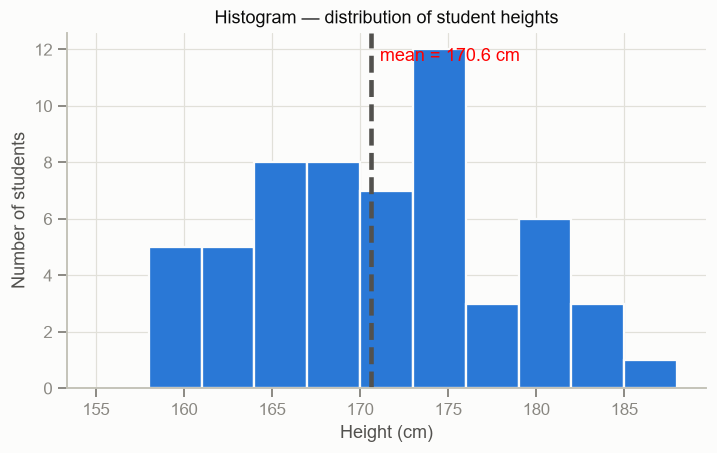

In [10]:
fig, ax = plt.subplots()
ax.hist(users["height_cm"].dropna(), bins=range(155, 190, 3),
        color=BLUE, edgecolor=SURFACE, linewidth=1.5)

mean_h = users["height_cm"].mean()
ax.axvline(mean_h, color=INK2, linestyle="--", linewidth=3)
ax.annotate(f"mean = {mean_h:.1f} cm", xy=(mean_h, ax.get_ylim()[1] * 0.92),
            xytext=(6, 0), textcoords="offset points", color='red')

ax.set_xlabel("Height (cm)")
ax.set_ylabel("Number of students")
ax.set_title("Histogram — distribution of student heights", loc="center")
plt.show()

fig.savefig("student_heights.png", dpi=300, bbox_inches="tight")

### 5.2 Density (KDE) plot

*Question: "What is the overall shape — and how does it differ between groups?"*

A kernel density estimate is a smoothed histogram, and it shines when **overlaying groups** where stacked histograms become unreadable. Here: height by gender (only the two groups with enough observations — a density of 1–2 points is pure smoothing artifact).


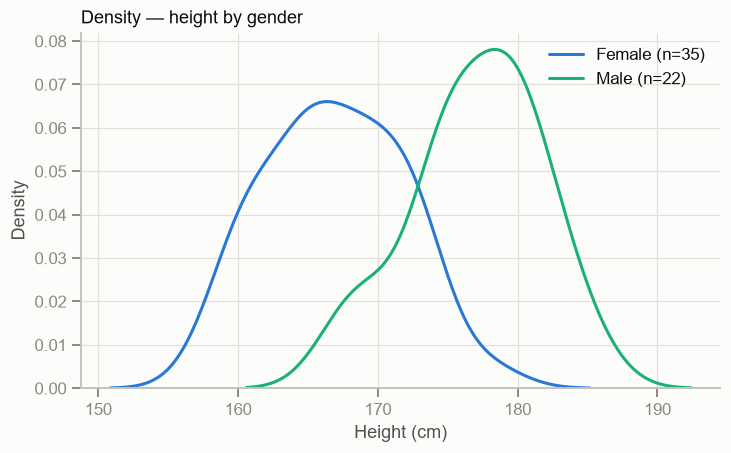

In [11]:
fig, ax = plt.subplots()
for g in ["Female", "Male"]:
    subset = users.loc[users["gender_label"] == g, "height_cm"].dropna()
    sns.kdeplot(subset, ax=ax, color=GENDER_COLORS[g], linewidth=2,
                label=f"{g} (n={len(subset)})")

ax.set_xlabel("Height (cm)")
ax.set_ylabel("Density")
ax.set_title("Density — height by gender", loc="left")
ax.legend(frameon=False)
plt.show()

### 5.3 ECDF plot

*Question: "What share of observations is at or below a given value?"*

The empirical cumulative distribution function makes no binning or smoothing choices at all, and quantiles read straight off it — the y-value at age 20 is the share of students aged 20 or younger.


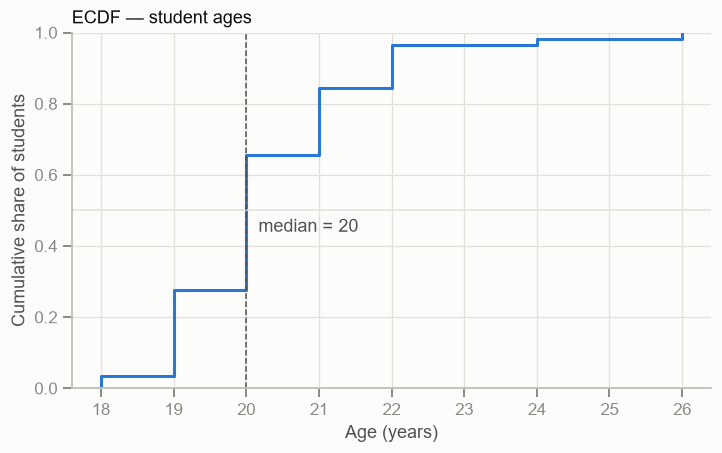

In [12]:
fig, ax = plt.subplots()
sns.ecdfplot(users["age"], ax=ax, color=BLUE, linewidth=2)

median_age = users["age"].median()
ax.axhline(0.5, color=GRID, linewidth=1)
ax.axvline(median_age, color=INK2, linestyle="--", linewidth=1)
ax.annotate(f"median = {median_age:.0f}", xy=(median_age, 0.5),
            xytext=(8, -14), textcoords="offset points", color=INK2)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Cumulative share of students")
ax.set_title("ECDF — student ages", loc="left")
plt.show()

## 6. Comparing categories

### 6.1 Bar chart — ordinal categories

*Question: "How large is each category?"*

Rules of thumb: start the axis at zero, label bars directly, and **sort by value — unless the categories have a natural order**. Study year is ordinal (1→4), so we keep its natural order instead of sorting by count.


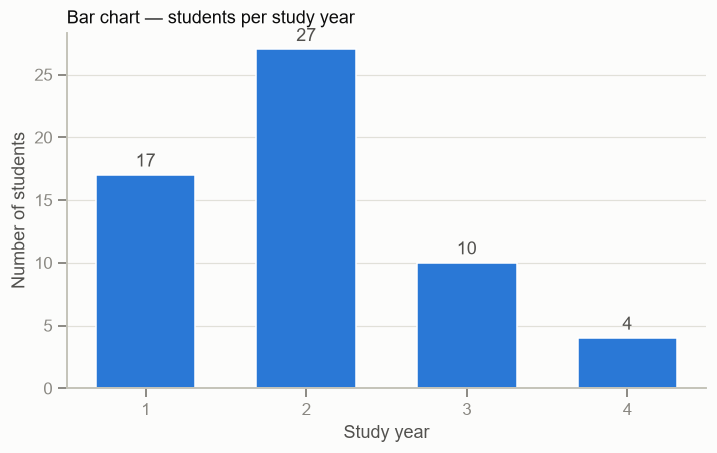

In [13]:
counts = users["study_year"].value_counts().sort_index()

fig, ax = plt.subplots()
bars = ax.bar(counts.index.astype(int).astype(str), counts.values,
              color=BLUE, width=0.62)
ax.bar_label(bars, padding=3, color=INK2)

ax.set_xlabel("Study year")
ax.set_ylabel("Number of students")
ax.set_title("Bar chart — students per study year", loc="left")
ax.grid(axis="x", visible=False)
plt.show()

### 6.2 Bar chart — nominal categories, sorted

Project titles have no natural order, so here we **do** sort by value, use horizontal bars (long labels stay readable), and label directly.


C:\Users\yuayao\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


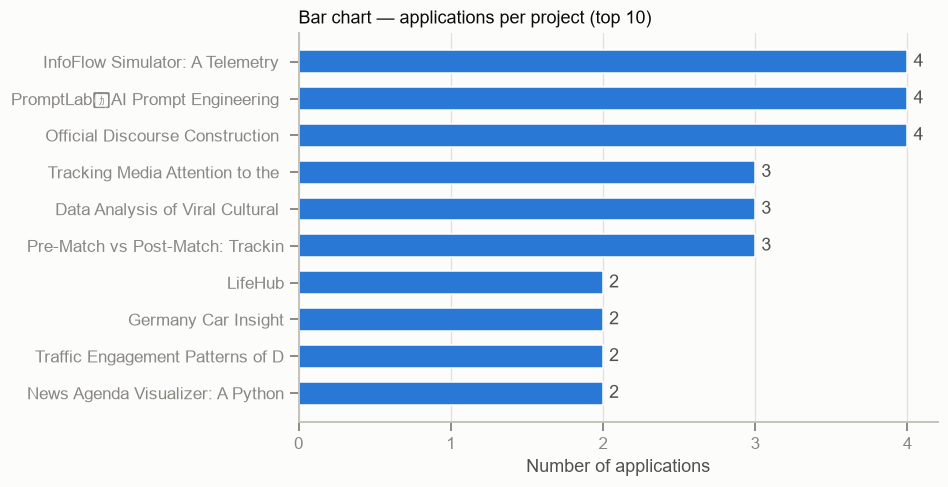

In [14]:
top = (projects.assign(short_title=projects["title"].str.slice(0, 32))
               .sort_values("n_applications")
               .tail(10))                      # 10 most-applied-to projects

fig, ax = plt.subplots(figsize=(7.5, 4.6))
bars = ax.barh(top["short_title"], top["n_applications"], color=BLUE, height=0.62)
ax.bar_label(bars, padding=4, color=INK2)

ax.set_xlabel("Number of applications")
ax.set_title("Bar chart — applications per project (top 10)", loc="left")
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))   # counts -> whole-number ticks
plt.show()

### 6.3 Box plot

*Question: "How does the **distribution** of a numeric variable differ across categories?"*

Each box shows median (line), interquartile range (box), whiskers, and outliers — the visual version of the grouped table in section 3. We keep only groups with enough data to summarize.


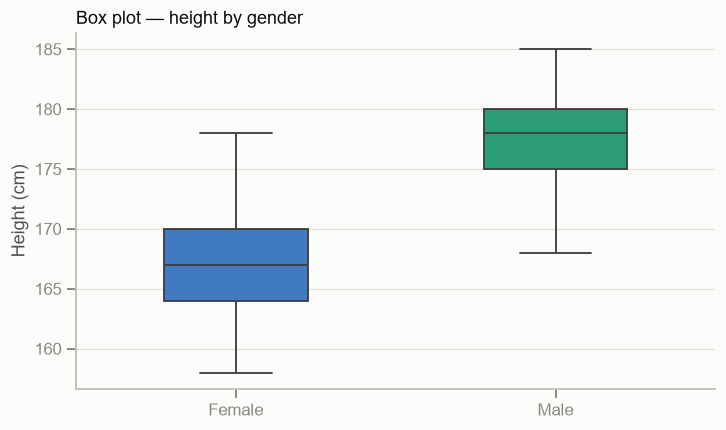

In [15]:
two = users[users["gender_label"].isin(["Female", "Male"])]

fig, ax = plt.subplots()
sns.boxplot(data=two, x="gender_label", y="height_cm",
            order=["Female", "Male"], hue="gender_label",
            palette=GENDER_COLORS, legend=False,
            width=0.45, linewidth=1.2, fliersize=3, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Height (cm)")
ax.set_title("Box plot — height by gender", loc="left")
ax.grid(axis="x", visible=False)
plt.show()

### 6.4 Violin plot

Same question as the box plot, but also shows the **shape** of each distribution (skew, bimodality) that a box hides. Needs a reasonable group size to be meaningful.


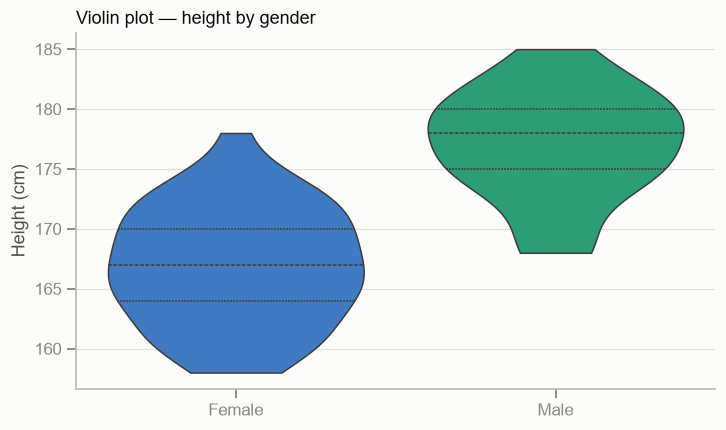

In [16]:
fig, ax = plt.subplots()
sns.violinplot(data=two, x="gender_label", y="height_cm",
               order=["Female", "Male"], hue="gender_label",
               palette=GENDER_COLORS, legend=False,
               inner="quart", linewidth=1, cut=0, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Height (cm)")
ax.set_title("Violin plot — height by gender", loc="left")
ax.grid(axis="x", visible=False)
plt.show()

## 7. Relationships and change over time

### 7.1 Scatter plot

*Question: "How do two numeric variables move together?"*

One point per **student**. Color encodes gender — the same fixed colors as every plot above. A little jitter on age (whole years) keeps overlapping points visible.


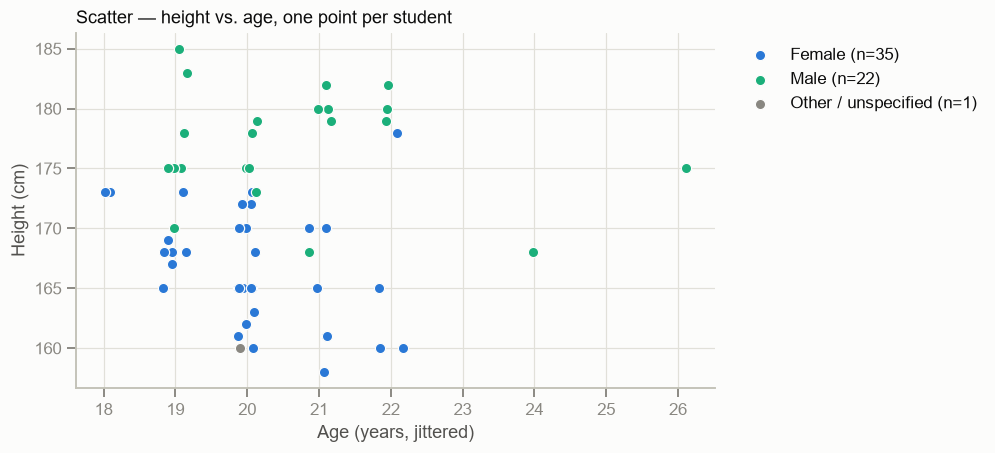

In [17]:
import numpy as np

rng = np.random.default_rng(42)
plot_df = users.dropna(subset=["age", "height_cm"]).copy()
plot_df["age_jitter"] = plot_df["age"] + rng.uniform(-0.18, 0.18, len(plot_df))

fig, ax = plt.subplots()
for g in GENDER_ORDER:
    sub = plot_df[plot_df["gender_label"] == g]
    ax.scatter(sub["age_jitter"], sub["height_cm"], s=45,
               color=GENDER_COLORS[g], label=f"{g} (n={len(sub)})",
               edgecolor=SURFACE, linewidth=0.8)

ax.set_xlabel("Age (years, jittered)")
ax.set_ylabel("Height (cm)")
ax.set_title("Scatter — height vs. age, one point per student", loc="left")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

### 7.2 Line / step plot over time

*Question: "How does a quantity change over time?"*

Every row carries a timestamp (`date_joined`), so we can plot **cumulative registrations**: sort by time, then count. The steep segments show when most of the class signed up.


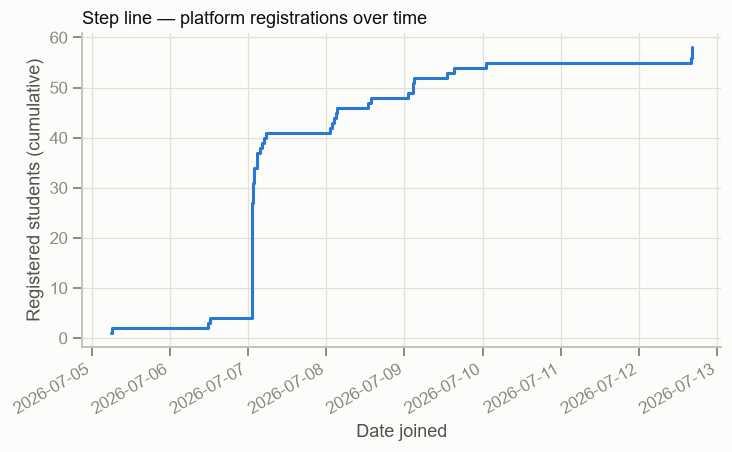

In [18]:
signups = users.sort_values("date_joined")

fig, ax = plt.subplots()
ax.step(signups["date_joined"], range(1, len(signups) + 1),
        where="post", color=BLUE, linewidth=2)

ax.set_xlabel("Date joined")
ax.set_ylabel("Registered students (cumulative)")
ax.set_title("Step line — platform registrations over time", loc="left")
fig.autofmt_xdate()
plt.show()

### 7.3 Correlation heatmap

*Question: "Which numeric variables are linearly related — across all pairs at once?"*

At the **project** grain: does asking for a bigger group attract more applications and end with more members? Correlations run from −1 to +1, so the color scale must be **diverging** (two hues meeting at neutral gray for 0), and cells are annotated because ±0.2 and ±0.5 look similar as color alone. With only 18 projects, treat these as descriptive, not conclusive.


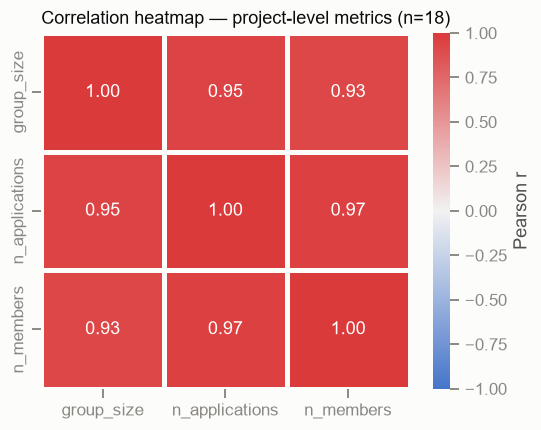

In [19]:
metrics = projects[["group_size", "n_applications", "n_members"]]
corr = metrics.corr()

fig, ax = plt.subplots(figsize=(5.4, 4.2))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, vmin=-1, vmax=1,
            cmap=sns.diverging_palette(255, 12, as_cmap=True),
            linewidths=2, linecolor=SURFACE,
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation heatmap — project-level metrics (n=18)", loc="left")
plt.show()

### 7.4 Pair plot

The scatter-plot matrix: every numeric variable against every other, distributions on the diagonal. Use it as a **first look** at a new dataset, not as a final figure — it is too dense to communicate one message.


In [ ]:
grid = sns.pairplot(two[["age", "height_cm", "study_year", "gender_label"]].dropna(),
                    hue="gender_label", palette=GENDER_COLORS,
                    hue_order=["Female", "Male"],
                    height=2.1, corner=True,
                    plot_kws={"s": 32, "edgecolor": SURFACE, "linewidth": 0.6})
grid.figure.suptitle("Pair plot — student-level variables", x=0.38, y=1.02)
plt.show()

## 8. Hypothesis testing

Everything so far *described* the data. Statistical **inference** asks a sharper question: *is a pattern we see strong enough that it is unlikely to be chance?* The recipe is always the same:

1. State the **null hypothesis H₀** ("no difference / no association").
2. Choose a test and a significance level **α** (conventionally 0.05).
3. Compute the test statistic and its **p-value** — the probability of seeing an effect at least this large *if H₀ were true*.
4. p < α → reject H₀. Otherwise we *fail to reject* it (we never "prove" H₀).

Two honest caveats for this dataset: **n is small** (limited power), and the class is **not a random sample** of any wider population — so conclusions describe this class, not students in general.

### 8.0 Features for the analysis

A few derived columns first: how many languages each student lists, whether they are active in any project (owner, applicant, or member), and an analysis frame restricted to the two gender groups large enough to compare.


In [ ]:
import numpy as np
from scipy import stats

# Number of languages listed ('Chinese, English' -> 2); split on common separators
users["n_languages"] = (users["languages"].fillna("")
                        .str.split(r"[,;/、和&]+", regex=True)
                        .apply(lambda parts: sum(1 for p in parts if p.strip())))

# Active in any project: owns one, applied to one, or is a member of one
active_ids = (set(projects["owner_id"])
              | set(applications["applicant_id"])
              | set(memberships["member_id"]))
users["in_project"] = users["id"].isin(active_ids)

# Analysis frame: the two comparable gender groups, complete numeric fields
two = users[users["gender_label"].isin(["Female", "Male"])].dropna(
    subset=["height_cm", "age"]).copy()

print(f"analysis frame: {len(two)} students")
users["in_project"].value_counts()

### 8.1 Two-sample t-test — do two group means differ?

*Question: is mean height different for female and male students?*
**H₀: the two population means are equal.**

We use **Welch's t-test** (`equal_var=False`), which does not assume the two groups have equal variances — a safer default than the classic Student's t-test. Alongside the p-value, always report the **confidence interval of the difference** (how big is the gap?) and an **effect size** (Cohen's d — is the gap large relative to the spread?).


In [ ]:
f = two.loc[two["gender_label"] == "Female", "height_cm"]
m = two.loc[two["gender_label"] == "Male", "height_cm"]
print(f"Female: n={len(f)}  mean={f.mean():.1f}  sd={f.std():.1f}")
print(f"Male:   n={len(m)}  mean={m.mean():.1f}  sd={m.std():.1f}")

res = stats.ttest_ind(m, f, equal_var=False)          # Welch's t-test
ci = res.confidence_interval()
print(f"\nWelch t = {res.statistic:.2f},  p = {res.pvalue:.2g}")
print(f"95% CI for mean difference (M − F): [{ci.low:.1f}, {ci.high:.1f}] cm")

# Effect size: Cohen's d with pooled standard deviation
sp = np.sqrt(((len(f) - 1) * f.var() + (len(m) - 1) * m.var()) / (len(f) + len(m) - 2))
print(f"Cohen's d = {(m.mean() - f.mean()) / sp:.2f}")

**Reading the output.** If p < 0.05 we reject H₀: the height difference is unlikely to be chance. The confidence interval says *how large* the difference plausibly is (it should not contain 0 when p < 0.05), and d ≈ 0.2 / 0.5 / 0.8 read as small / medium / large.

The t-test assumes roughly normal groups (or decent group sizes). When that is doubtful — heavy skew, outliers, tiny groups — use the nonparametric **Mann-Whitney U test**, which compares distributions using ranks only:


In [ ]:
u = stats.mannwhitneyu(m, f, alternative="two-sided")
print(f"Mann-Whitney U = {u.statistic:.0f},  p = {u.pvalue:.2g}")

### 8.2 Chi-square test — are two categorical variables associated?

*Question: is project participation associated with gender?*
**H₀: `gender` and `in_project` are independent.**

The chi-square test compares the **observed** contingency table with the counts **expected under independence**. Validity rule of thumb: all expected counts should be ≥ 5 — with a small table that fails easily, and the fallback is **Fisher's exact test** (exact for 2×2 tables, no minimum-count rule).


In [ ]:
ct = pd.crosstab(two["gender_label"], two["in_project"])
print("Observed counts:")
print(ct)

chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"\nchi² = {chi2:.2f},  dof = {dof},  p = {p:.2g}")
print("\nExpected counts under independence:")
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))

# Small 2x2 table -> Fisher's exact test is the more trustworthy answer
odds, p_fisher = stats.fisher_exact(ct)
print(f"\nFisher's exact test: odds ratio = {odds:.2f},  p = {p_fisher:.2g}")

**Reading the output.** A large p means the observed table is entirely compatible with independence — participation does not differ detectably by gender. If any expected count is below 5, quote Fisher's exact test instead of the chi-square.

## 9. Regression

Hypothesis tests answer *"is there a difference?"*. Regression answers the richer question: *"**how** does an outcome depend on one or more predictors — and by how much?"*

### 9.1 Simple linear regression

*Model: `height_cm ~ age` — does age predict height in this class?*

`statsmodels` formula syntax reads like the model itself: outcome on the left of `~`, predictors on the right.


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

m1 = smf.ols("height_cm ~ age", data=two).fit()
print(m1.summary())

**How to read the summary** (the three numbers that matter first):

- **coef (age)** — the slope: predicted change in height (cm) per extra year of age.
- **P>|t|** — the p-value for H₀: *slope = 0*. If it is large, age tells us nothing about height here (as expected — these students are all adults).
- **R-squared** — share of height variance the model explains. Near 0 = the model is not useful.

A single weak predictor is not the end of the story — regression becomes powerful when we add the *right* predictor.

### 9.2 Multiple regression with a categorical predictor

*Model: `height_cm ~ age + C(gender_label)` — `C()` turns a categorical column into dummy (0/1) variables.*


In [ ]:
m2 = smf.ols("height_cm ~ age + C(gender_label)", data=two).fit()
print(m2.summary())

**Reading the coefficients.** `C(gender_label)[T.Male]` is the **dummy coefficient**: holding age constant, male students are on average that many cm taller than the baseline category (Female). Compare R-squared with model 1 — adding the right predictor explains far more variance than age ever did.

The fitted model is two **parallel lines** (same age slope, different intercepts):


In [ ]:
fig, ax = plt.subplots()
ages = np.linspace(two["age"].min(), two["age"].max(), 50)
for g in ["Female", "Male"]:
    sub = two[two["gender_label"] == g]
    ax.scatter(sub["age"], sub["height_cm"], s=38, color=GENDER_COLORS[g],
               edgecolor=SURFACE, linewidth=0.8, label=f"{g} (n={len(sub)})")
    pred = m2.predict(pd.DataFrame({"age": ages, "gender_label": g}))
    ax.plot(ages, pred, color=GENDER_COLORS[g], linewidth=2)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Height (cm)")
ax.set_title("Multiple regression — parallel fits by gender", loc="left")
ax.legend(frameon=False)
plt.show()

**Always check the residuals.** OLS assumes the errors are roughly symmetric around zero with constant spread. Two standard diagnostic plots: residuals vs. fitted (look for *no* pattern — a funnel or curve means trouble) and a normal Q-Q plot (points near the line = residuals roughly normal).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

axes[0].scatter(m2.fittedvalues, m2.resid, s=30, color=BLUE,
                edgecolor=SURFACE, linewidth=0.6)
axes[0].axhline(0, color=INK2, linewidth=1)
axes[0].set_xlabel("Fitted values (cm)")
axes[0].set_ylabel("Residuals (cm)")
axes[0].set_title("Residuals vs. fitted", loc="left")

sm.qqplot(m2.resid, line="s", ax=axes[1], markerfacecolor=BLUE,
          markeredgecolor=SURFACE, alpha=0.9)
axes[1].set_title("Normal Q-Q plot of residuals", loc="left")

plt.tight_layout()
plt.show()

### 9.3 Logistic regression — a binary outcome

Linear regression needs a numeric outcome. When the outcome is **binary**, we model the *probability* of one class with **logistic regression**.

Classic demo with this data: *model the probability that a student is in the male group, given height.* (A statistics exercise, not a claim about individuals — the two height distributions overlap heavily, which is exactly why a probabilistic model is the right tool.)

*Model: `is_male ~ height_cm`.* Coefficients live on the **log-odds** scale; `exp(coef)` is the **odds ratio** per unit of the predictor.


In [ ]:
two["is_male"] = (two["gender_label"] == "Male").astype(int)

logit = smf.logit("is_male ~ height_cm", data=two).fit()
print(logit.summary())

or_per_cm = np.exp(logit.params["height_cm"])
print(f"\nOdds ratio: each extra cm multiplies the odds of 'male' by {or_per_cm:.2f}")

The fitted model is an S-shaped (sigmoid) probability curve:


In [ ]:
heights = np.linspace(155, 190, 200)
p_hat = logit.predict(pd.DataFrame({"height_cm": heights}))

rng = np.random.default_rng(1)
jitter = rng.uniform(-0.04, 0.04, len(two))

fig, ax = plt.subplots()
ax.plot(heights, p_hat, color=INK2, linewidth=2, label="fitted P(male | height)")
ax.scatter(two["height_cm"], two["is_male"] + jitter, s=30,
           c=two["gender_label"].map(GENDER_COLORS),
           edgecolor=SURFACE, linewidth=0.6)
ax.axhline(0.5, color=GRID, linewidth=1)
ax.annotate("decision threshold 0.5", xy=(156, 0.52), color=MUTED, fontsize=9)

ax.set_xlabel("Height (cm)")
ax.set_ylabel("P(male)")
ax.set_title("Logistic regression — probability curve with observed data", loc="left")
ax.legend(frameon=False, loc="center right")
plt.show()

**Using the model as a classifier.** Predict "male" when the fitted probability exceeds 0.5, then compare with reality. Judge accuracy against the **majority-class baseline** (always guessing the larger group), not against 0%:


In [ ]:
pred = (logit.predict(two) >= 0.5).astype(int)

print(pd.crosstab(two["is_male"], pred,
                  rownames=["actual"], colnames=["predicted"]))
baseline = max(two["is_male"].mean(), 1 - two["is_male"].mean())
print(f"\naccuracy = {(pred == two['is_male']).mean():.0%}"
      f"   (majority-class baseline = {baseline:.0%})")

### 9.4 Exercises

Try these yourself — every ingredient is already in this notebook:

1. **ANOVA** (`stats.f_oneway`): does mean height differ across study years (1–4)?
2. **Chi-square**: is `study_year` associated with `gender_label`? Check the expected counts — is the test even valid here?
3. **Linear regression**: `n_languages ~ study_year` — do senior students list more languages?
4. **Logistic regression**: `in_project ~ study_year + C(gender_label) + n_languages` — does anything predict who joins a project? (Expect wide confidence intervals: n is small and most students participate.)

## 10. Cheat sheet

### Which plot for which question?

| You want to show… | Use | Section |
|---|---|---|
| The distribution of one numeric variable | Histogram / KDE / ECDF | 5.1–5.3 |
| Sizes of categories | Bar chart (zero-based, labeled; sort nominal, keep ordinal order) | 6.1–6.2 |
| A numeric distribution *per category* | Box plot (summary) / violin (shape) | 6.3–6.4 |
| The relationship between two numeric variables | Scatter plot | 7.1 |
| Change over time | Line / step plot | 7.2 |
| All pairwise linear relationships | Correlation heatmap / pair plot | 7.3–7.4 |

### Which test / model for which question?

| You want to know… | Method | Section |
|---|---|---|
| Do two group means differ? | Welch t-test (Mann-Whitney if non-normal) | 8.1 |
| Are two categorical variables associated? | Chi-square (Fisher's exact for small 2×2) | 8.2 |
| How does a numeric outcome depend on predictors? | Linear regression (OLS) + residual checks | 9.1–9.2 |
| How does a binary outcome depend on predictors? | Logistic regression, odds ratios | 9.3 |

Habits worth keeping:

- Know the **grain** of each table (per student vs. per project) before plotting.
- Keep **one fixed color per category** across all figures.
- **Free-text columns are not categories** until cleaned (section 3.1).
- Drop or merge groups too small to summarize; say so in the caption.
- Diverging color scales only for signed quantities (like correlations).
- Report **effect sizes and confidence intervals** alongside p-values — "significant" is not the same as "large".
- Check regression **residuals** before trusting coefficients.
- With small n, results describe *this class*, they don't estimate a population.

Finally, release the database connections held by this notebook:


In [ ]:
engine.dispose()